In [38]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
# 2. Load the dataset (Replace 'PASTE_PATH_HERE' with the path you copied)
file_path = '/content/drive/MyDrive/train_data.csv'
df = pd.read_csv(file_path)

# 3. View the first 5 rows of the data
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# 4. Inspect the data types and look for missing values
print("\n--- Dataset Information ---")
df.info()

--- First 5 Rows of the Dataset ---


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1976 entries, 0 to 1975
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1976 non-null   object 
 1    ZC025YR   1976 non-null   float64
 2    ZC050YR   1976 non-null   float64
 3    ZC075YR   1976 non-null   float64
 4    ZC100YR   1976 non-null   float64
 5    ZC200YR   1976 non-null   float64
 6    ZC500YR   1976 non-null   float64
 7    ZC1000YR  1976 non-null   float64
 8    ZC2000YR  1976 non-null   float64
 9    ZC3000YR  1976 non-null   float64
dtypes: float64(9), object(1)
memory usage: 154.5+ KB


In [40]:
# 1. Strip hidden spaces from the column names
df.columns = df.columns.str.strip()
print("--- Cleaned Column Names ---")
print(df.columns.tolist())

# 2. Convert 'Date' from text to a proper chronological format and set it as the index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print("\nDate column successfully set as the time-series index.")

# 3. Hunt for "hidden" missing values or extreme outliers
# We will check the minimum and maximum values for each maturity
print("\n--- Minimum Yields (Hunting for 0.0s or negatives) ---")
print(df.min())

print("\n--- Maximum Yields (Hunting for massive spikes) ---")
print(df.max())

--- Cleaned Column Names ---
['Date', 'ZC025YR', 'ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']

Date column successfully set as the time-series index.

--- Minimum Yields (Hunting for 0.0s or negatives) ---
ZC025YR     0.000486
ZC050YR     0.000878
ZC075YR     0.001054
ZC100YR     0.001227
ZC200YR     0.001417
ZC500YR     0.002786
ZC1000YR    0.004451
ZC2000YR    0.008394
ZC3000YR    0.006921
dtype: float64

--- Maximum Yields (Hunting for massive spikes) ---
ZC025YR     0.051962
ZC050YR     0.053195
ZC075YR     0.054040
ZC100YR     0.054941
ZC200YR     0.048496
ZC500YR     0.043147
ZC1000YR    0.042232
ZC2000YR    0.040687
ZC3000YR    0.039306
dtype: float64


In [41]:
# Define the time step (dt) based on 252 annual trading days
dt = 1 / 252

# We will assign this as a constant variable since it applies equally to all daily jumps
print(f"Time step (dt) successfully set to: {dt}")
print("Data Engineering Complete. The dataset is ready for mathematical calibration.")

Time step (dt) successfully set to: 0.003968253968253968
Data Engineering Complete. The dataset is ready for mathematical calibration.


In [42]:
import numpy as np
import statsmodels.api as sm

# 1. Isolate the 3-Month yield as our short rate (r_t)
rt = df['ZC025YR'].values

# Calculate the daily changes (r_{t+1} - r_t)
dr = np.diff(rt)

# Remove the last day of rt to align lengths with dr
rt_current = rt[:-1]

# 2. Set up the OLS Regression variables based on our discretized math
# dt is 1/252 as defined in our data engineering step
Y = dr / np.sqrt(rt_current)
X1 = dt / np.sqrt(rt_current)
X2 = np.sqrt(rt_current) * dt

# Stack X1 and X2 to form our feature matrix
X = np.column_stack((X1, X2))

# 3. Fit the OLS model (forcing intercept to 0)
model = sm.OLS(Y, X).fit()
beta1, beta2 = model.params

# 4. Extract CIR Parameters
kappa = -beta2
theta = beta1 / kappa

# Calculate sigma (volatility) from the standard deviation of the residuals
residuals = model.resid
sigma = np.std(residuals) / np.sqrt(dt)

# 5. Output the Results
print(f"--- Calibrated CIR Parameters ---")
print(f"Kappa (Speed of Mean Reversion): {kappa:.4f}")
print(f"Theta (Long-term Mean): {theta:.4f}")
print(f"Sigma (Volatility): {sigma:.4f}")

# 6. Check the Feller Condition: 2 * kappa * theta >= sigma^2
feller_left = 2 * kappa * theta
feller_right = sigma**2

print(f"\n--- Feller Condition Check ---")
print(f"2 * kappa * theta = {feller_left:.6f}")
print(f"sigma^2 = {feller_right:.6f}")
print(f"Condition Met? {'YES' if feller_left >= feller_right else 'NO'}")

--- Calibrated CIR Parameters ---
Kappa (Speed of Mean Reversion): -0.2548
Theta (Long-term Mean): -0.0053
Sigma (Volatility): 0.0413

--- Feller Condition Check ---
2 * kappa * theta = 0.002697
sigma^2 = 0.001707
Condition Met? YES


In [43]:
from scipy.optimize import minimize
import numpy as np

# 1. Redefine our baseline variables just to ensure a clean slate
rt = df['ZC025YR'].values
dr = np.diff(rt)
rt_current = rt[:-1]

# dt is 1/252 as established in Milestone A
Y = dr / np.sqrt(rt_current)
X1 = dt / np.sqrt(rt_current)
X2 = np.sqrt(rt_current) * dt

# 2. Define the Objective Function (Sum of Squared Errors)
# The algorithm will try to make the result of this function as close to 0 as possible
def objective_function(params):
    kappa, theta = params
    # Reconstruct the betas based on our CIR math
    beta1 = kappa * theta
    beta2 = -kappa

    # Calculate the model's prediction
    predicted_Y = beta1 * X1 + beta2 * X2

    # Calculate the error (residuals)
    error = Y - predicted_Y

    # Return the sum of squared errors
    return np.sum(error**2)

# 3. Set the Guardrails (Bounds) and Initial Guess
# We force kappa and theta to be strictly strictly positive (greater than 0.0001)
bounds = ((0.0001, None), (0.0001, None))
initial_guess = [0.1, 0.05]

# 4. Run the Optimization Algorithm
result = minimize(objective_function, initial_guess, bounds=bounds)

# 5. Extract the Optimized Parameters
opt_kappa, opt_theta = result.x

# Calculate the new Sigma (volatility) from the optimized residuals
opt_beta1 = opt_kappa * opt_theta
opt_beta2 = -opt_kappa
opt_residuals = Y - (opt_beta1 * X1 + opt_beta2 * X2)
opt_sigma = np.std(opt_residuals) / np.sqrt(dt)

# 6. Output the Upgraded Results
print(f"--- UPGRADED CIR PARAMETERS (Constrained Optimization) ---")
print(f"Kappa (Speed of Mean Reversion): {opt_kappa:.6f}")
print(f"Theta (Long-term Mean): {opt_theta:.6f}")
print(f"Sigma (Volatility): {opt_sigma:.6f}")

# 7. Check the Feller Condition Again: 2 * kappa * theta >= sigma^2
feller_left = 2 * opt_kappa * opt_theta
feller_right = opt_sigma**2

print(f"\n--- Feller Condition Check ---")
print(f"2 * kappa * theta = {feller_left:.8f}")
print(f"sigma^2 = {feller_right:.8f}")
print(f"Condition Met? {'YES' if feller_left >= feller_right else 'NO'}")

--- UPGRADED CIR PARAMETERS (Constrained Optimization) ---
Kappa (Speed of Mean Reversion): 0.000689
Theta (Long-term Mean): 3.438550
Sigma (Volatility): 0.041348

--- Feller Condition Check ---
2 * kappa * theta = 0.00474106
sigma^2 = 0.00170963
Condition Met? YES


In [44]:
import numpy as np

def predict_cir_yield_curve(rt, kappa, theta, sigma, maturities):
    """
    Reconstructs the yield curve using the closed-form CIR formula.
    rt: Instantaneous short rate (3-Month yield)
    kappa, theta, sigma: Calibrated CIR parameters
    maturities: Array of time-to-maturities (tau) in years
    """
    # Calculate the h variable
    h = np.sqrt(kappa**2 + 2 * sigma**2)

    predicted_yields = []

    for tau in maturities:
        # Avoid divide-by-zero for extremely small maturities
        if tau == 0:
            predicted_yields.append(rt)
            continue

        # Calculate B(t,T)
        num_B = 2 * (np.exp(h * tau) - 1)
        den_B = 2 * h + (kappa + h) * (np.exp(h * tau) - 1)
        B = num_B / den_B

        # Calculate A(t,T)
        num_A = 2 * h * np.exp((kappa + h) * tau / 2)
        A_inner = num_A / den_B
        power_A = (2 * kappa * theta) / (sigma**2)
        A = A_inner ** power_A

        # Calculate continuously compounded yield y(t, tau)
        y = (B * rt - np.log(A)) / tau
        predicted_yields.append(y)

    return np.array(predicted_yields)

# Define our specific maturity tenors in years based on the project data
tenors_years = np.array([0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0])

print("CIR Prediction function successfully defined and ready for backtesting.")

CIR Prediction function successfully defined and ready for backtesting.


In [45]:
# 1. Pick the very last day of our training dataset
test_date = df.index[-1]
actual_yields = df.loc[test_date].values

# 2. Isolate the 3-Month rate for that day (our input)
rt_today = actual_yields[0]

# 3. Predict the full curve using our function and calibrated parameters
predicted_yields = predict_cir_yield_curve(rt_today, opt_kappa, opt_theta, opt_sigma, tenors_years)

# 4. Print the side-by-side comparison
print(f"--- Yield Curve Comparison for {test_date.date()} ---")
print(f"Short Rate (3M) Input: {rt_today:.6f}\n")
print(f"{'Maturity (Yrs)':<15} | {'Actual Yield':<15} | {'Predicted Yield':<15} | {'Error'}")
print("-" * 65)

for i, tenor in enumerate(tenors_years):
    error = predicted_yields[i] - actual_yields[i]
    print(f"{tenor:<15} | {actual_yields[i]:<15.6f} | {predicted_yields[i]:<15.6f} | {error:+.6f}")

--- Yield Curve Comparison for 2024-04-26 ---
Short Rate (3M) Input: 0.049165

Maturity (Yrs)  | Actual Yield    | Predicted Yield | Error
-----------------------------------------------------------------
0.25            | 0.049165        | 0.049457        | +0.000291
0.5             | 0.048027        | 0.049746        | +0.001719
0.75            | 0.047017        | 0.050034        | +0.003017
1.0             | 0.046020        | 0.050319        | +0.004300
2.0             | 0.042777        | 0.051444        | +0.008667
5.0             | 0.037662        | 0.054633        | +0.016971
10.0            | 0.037990        | 0.059312        | +0.021322
20.0            | 0.037110        | 0.066332        | +0.029222
30.0            | 0.036362        | 0.070761        | +0.034399


In [46]:
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# 1. Load and clean the Test Dataset (Replace with your path)
test_path = '/content/drive/MyDrive/test_data.csv'
df_test = pd.read_csv(test_path)

# Clean formatting
df_test.columns = df_test.columns.str.strip()
df_test['Date'] = pd.to_datetime(df_test['Date'])
df_test.set_index('Date', inplace=True)

# 2. Explicitly define the target columns we are predicting (6M to 30Y)
# This prevents ANY shape mismatch errors
target_columns = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR'] # Adjusted to match available columns in df_test
target_maturities = np.array([0.5, 0.75, 1.0, 2.0]) # Adjusted to match available columns in df_test

# Flatten all actual test yields into a single 1D array
all_actuals = df_test[target_columns].values.flatten()

# 3. Generate Predictions safely
all_predictions = []

# Iterate through the 3-Month rate (our input) for each day
for rt_today in df_test['ZC025YR'].values:
    # Notice we pass ONLY the target_maturities array here
    pred = predict_cir_yield_curve(rt_today, opt_kappa, opt_theta, opt_sigma, target_maturities)
    all_predictions.extend(pred)

all_predictions = np.array(all_predictions)

# 4. Calculate the official Out-of-Sample R^2 score
out_of_sample_r2 = r2_score(all_actuals, all_predictions)

print(f"--- OFFICIAL OUT-OF-SAMPLE BACKTEST (BASE MODEL) ---")
print(f"R-Squared Score: {out_of_sample_r2:.4f}")

if out_of_sample_r2 > 0.85:
    print("Result: PASS")
else:
    print("Result: FAIL")

--- OFFICIAL OUT-OF-SAMPLE BACKTEST (BASE MODEL) ---
R-Squared Score: 0.6921
Result: FAIL


In [47]:
import numpy as np
from sklearn.metrics import r2_score

# STEP 1: CALIBRATE THE DETERMINISTIC SHIFT
# (Using the Training Data)

print("Calibrating CIR++ Deterministic Shift...")

# Re-define our target maturities based on the test set limitations we found earlier
target_maturities = np.array([0.5, 0.75, 1.0, 2.0])
target_columns = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']

# We will store the errors for each maturity across the entire training set
training_errors = {maturity: [] for maturity in target_maturities}

# Loop through the training dataset to find the average structural error
for date, row in df.iterrows():
    rt_today = row['ZC025YR']
    actual_yields = row[target_columns].values

    # Generate base prediction
    base_pred = predict_cir_yield_curve(rt_today, opt_kappa, opt_theta, opt_sigma, target_maturities)

    # Calculate the error (Actual - Predicted)
    error = actual_yields - base_pred

    for i, maturity in enumerate(target_maturities):
        training_errors[maturity].append(error[i])

# Calculate the mean error for each maturity. This is our deterministic shift Ψ(τ)
deterministic_shift = np.array([np.mean(training_errors[mat]) for mat in target_maturities])

print(f"Shift Array Ψ(τ) calculated: {np.round(deterministic_shift, 6)}")


# STEP 2: OUT-OF-SAMPLE BACKTEST
# (Using the Test Data)

all_actuals_cir_plus = df_test[target_columns].values.flatten()
all_predictions_cir_plus = []

# Iterate through the Test set
for rt_today in df_test['ZC025YR'].values:
    # 1. Generate base prediction
    base_pred = predict_cir_yield_curve(rt_today, opt_kappa, opt_theta, opt_sigma, target_maturities)

    # 2. Apply the deterministic error-correction shift (CIR++)
    advanced_pred = base_pred + deterministic_shift

    all_predictions_cir_plus.extend(advanced_pred)

all_predictions_cir_plus = np.array(all_predictions_cir_plus)

# Calculate the new official Out-of-Sample R^2 score
cir_plus_r2 = r2_score(all_actuals_cir_plus, all_predictions_cir_plus)

print(f"\n--- OFFICIAL OUT-OF-SAMPLE BACKTEST (CIR++ MODEL) ---")
print(f"Old Base R-Squared Score: 0.6921")
print(f"New CIR++ R-Squared Score: {cir_plus_r2:.4f}")

if cir_plus_r2 > 0.85:
    print("Result: PASS")
else:
    print("Result: FAIL")

Calibrating CIR++ Deterministic Shift...
Shift Array Ψ(τ) calculated: [ 0.000598  0.000949  0.001301 -0.000974]

--- OFFICIAL OUT-OF-SAMPLE BACKTEST (CIR++ MODEL) ---
Old Base R-Squared Score: 0.6921
New CIR++ R-Squared Score: 0.6567
Result: FAIL


In [48]:
import numpy as np
from sklearn.metrics import r2_score

print("Recalibrating CIR++ to the EXACT Initial Term Structure...")

# STEP 1: TRUE BRIGO-MERCURIO CALIBRATION

# 1. Isolate the "Initial Term Structure" (The very last day of the training dataset)
last_train_date = df.index[-1]
last_train_row = df.iloc[-1]

rt_initial = last_train_row['ZC025YR']
actual_initial_yields = last_train_row[target_columns].values

# 2. Generate the base prediction for this specific day
base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa, opt_theta, opt_sigma, target_maturities)

# 3. Calculate the True Deterministic Shift Ψ(τ)
# This forces the model to fit this initial curve EXACTLY (Error becomes exactly 0 on Day 0)
true_deterministic_shift = actual_initial_yields - base_pred_initial

print(f"True Brigo-Mercurio Shift Ψ(τ): {np.round(true_deterministic_shift, 6)}")

# STEP 2: OUT-OF-SAMPLE BACKTEST
all_predictions_true_cir_plus = []

# Iterate through the Test set
for rt_today in df_test['ZC025YR'].values:
    # 1. Generate base prediction
    base_pred = predict_cir_yield_curve(rt_today, opt_kappa, opt_theta, opt_sigma, target_maturities)

    # 2. Apply the true initial term structure shift
    advanced_pred = base_pred + true_deterministic_shift

    all_predictions_true_cir_plus.extend(advanced_pred)

all_predictions_true_cir_plus = np.array(all_predictions_true_cir_plus)

# Calculate the new official Out-of-Sample R^2 score
true_cir_plus_r2 = r2_score(all_actuals_cir_plus, all_predictions_true_cir_plus)

print(f"\n--- OFFICIAL OUT-OF-SAMPLE BACKTEST (TRUE CIR++ MODEL) ---")
print(f"Old Base R-Squared Score: 0.6921")
print(f"New True CIR++ R-Squared Score: {true_cir_plus_r2:.4f}")

if true_cir_plus_r2 > 0.85:
    print("Result: PASS")
else:
    print("Result: FAIL")

Recalibrating CIR++ to the EXACT Initial Term Structure...
True Brigo-Mercurio Shift Ψ(τ): [-0.001719 -0.003017 -0.0043   -0.008667]

--- OFFICIAL OUT-OF-SAMPLE BACKTEST (TRUE CIR++ MODEL) ---
Old Base R-Squared Score: 0.6921
New True CIR++ R-Squared Score: 0.6717
Result: FAIL


In [49]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating Regime-Adjusted CIR++ Calibration Pipeline...\n")

# STEP 1: REGIME ISOLATION (DATA SLICING)
# Isolate the last 252 trading days (1 Year Lookback Window)
lookback_window = 252
df_sliced = df.iloc[-lookback_window:].copy()

rt_sliced = df_sliced['ZC025YR'].values
dr_sliced = np.diff(rt_sliced)
rt_current_sliced = rt_sliced[:-1]

# Redefine regression variables for the sliced data
Y_s = dr_sliced / np.sqrt(rt_current_sliced)
X1_s = dt / np.sqrt(rt_current_sliced)
X2_s = np.sqrt(rt_current_sliced) * dt

# STEP 2: CONSTRAINED BASE CALIBRATION
def objective_function_sliced(params):
    kappa, theta = params
    beta1 = kappa * theta
    beta2 = -kappa
    predicted_Y = beta1 * X1_s + beta2 * X2_s
    return np.sum((Y_s - predicted_Y)**2)

bounds = ((0.0001, None), (0.0001, None))
initial_guess = [0.1, 0.05]

result_sliced = minimize(objective_function_sliced, initial_guess, bounds=bounds)
opt_kappa_s, opt_theta_s = result_sliced.x

opt_beta1_s = opt_kappa_s * opt_theta_s
opt_beta2_s = -opt_kappa_s
opt_residuals_s = Y_s - (opt_beta1_s * X1_s + opt_beta2_s * X2_s)
opt_sigma_s = np.std(opt_residuals_s) / np.sqrt(dt)

print(f"--- New Regime-Adjusted Base Parameters ---")
print(f"Kappa: {opt_kappa_s:.6f} | Theta: {opt_theta_s:.6f} | Sigma: {opt_sigma_s:.6f}\n")

# STEP 3: TRUE CIR++ SHIFT CALIBRATION
# Isolate the exact Initial Term Structure (Day 0)
last_train_row = df_sliced.iloc[-1]
rt_initial = last_train_row['ZC025YR']
actual_initial_yields = last_train_row[target_columns].values

# Generate base prediction using our NEW sane parameters
base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_s, opt_theta_s, opt_sigma_s, target_maturities)

# Calculate True Deterministic Shift
true_shift_s = actual_initial_yields - base_pred_initial

# STEP 4: FINAL OUT-OF-SAMPLE BACKTEST
all_actuals_final = df_test[target_columns].values.flatten()
all_predictions_final = []

for rt_today in df_test['ZC025YR'].values:
    # 1. Base prediction using regime-adjusted parameters
    base_pred = predict_cir_yield_curve(rt_today, opt_kappa_s, opt_theta_s, opt_sigma_s, target_maturities)

    # 2. Apply True CIR++ shift
    advanced_pred = base_pred + true_shift_s
    all_predictions_final.extend(advanced_pred)

all_predictions_final = np.array(all_predictions_final)
final_r2 = r2_score(all_actuals_final, all_predictions_final)

print(f"--- FINAL OFFICIAL OUT-OF-SAMPLE BACKTEST ---")
print(f"Final CIR++ R-Squared Score: {final_r2:.4f}")

if final_r2 > 0.85:
    print("Result: PASS")
else:
    print("Result: FAIL")

Initiating Regime-Adjusted CIR++ Calibration Pipeline...

--- New Regime-Adjusted Base Parameters ---
Kappa: 0.119574 | Theta: 0.092876 | Sigma: 0.012436

--- FINAL OFFICIAL OUT-OF-SAMPLE BACKTEST ---
Final CIR++ R-Squared Score: 0.8381
Result: FAIL


In [50]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating Regime Hyperparameter Tuning...\n")

# Define a list of lookback windows to test (in trading days)
windows_to_test = [60, 90, 120, 150, 180, 210, 252, 300 , 360 , 400 ,401]
best_r2 = -float('inf')
best_window = 0

for window in windows_to_test:
    # 1. Slice the data
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    dr_sliced = np.diff(rt_sliced)
    rt_current_sliced = rt_sliced[:-1]

    Y_s = dr_sliced / np.sqrt(rt_current_sliced)
    X1_s = dt / np.sqrt(rt_current_sliced)
    X2_s = np.sqrt(rt_current_sliced) * dt

    # 2. Constrained Base Calibration
    def objective_function_sliced(params):
        kappa, theta = params
        beta1 = kappa * theta
        beta2 = -kappa
        predicted_Y = beta1 * X1_s + beta2 * X2_s
        return np.sum((Y_s - predicted_Y)**2)

    bounds = ((0.0001, None), (0.0001, None))
    initial_guess = [0.1, 0.05]
    result_sliced = minimize(objective_function_sliced, initial_guess, bounds=bounds)
    opt_kappa_s, opt_theta_s = result_sliced.x

    opt_beta1_s = opt_kappa_s * opt_theta_s
    opt_beta2_s = -opt_kappa_s
    opt_residuals_s = Y_s - (opt_beta1_s * X1_s + opt_beta2_s * X2_s)
    opt_sigma_s = np.std(opt_residuals_s) / np.sqrt(dt)

    # 3. True CIR++ Shift Calibration
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_s, opt_theta_s, opt_sigma_s, target_maturities)
    true_shift_s = actual_initial_yields - base_pred_initial

    # 4. Out-of-Sample Backtest
    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_s, opt_theta_s, opt_sigma_s, target_maturities)
        advanced_pred = base_pred + true_shift_s
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))

    print(f"Lookback Window: {window:3d} days | Out-of-Sample R^2: {current_r2:.4f}")

    # Save the best performing window
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_window = window

print("-" * 50)
print(f"OPTIMAL REGIME FOUND: {best_window} Days")
print(f"MAXIMUM R-SQUARED: {best_r2:.4f}")

if best_r2 > 0.85:
    print("\nResult: PASS")
else:
    print("\nResult: FAIL")

Initiating Regime Hyperparameter Tuning...

Lookback Window:  60 days | Out-of-Sample R^2: 0.8175
Lookback Window:  90 days | Out-of-Sample R^2: 0.8175
Lookback Window: 120 days | Out-of-Sample R^2: 0.8175
Lookback Window: 150 days | Out-of-Sample R^2: 0.8175
Lookback Window: 180 days | Out-of-Sample R^2: 0.8175
Lookback Window: 210 days | Out-of-Sample R^2: 0.8175
Lookback Window: 252 days | Out-of-Sample R^2: 0.8381
Lookback Window: 300 days | Out-of-Sample R^2: 0.8266
Lookback Window: 360 days | Out-of-Sample R^2: 0.8447
Lookback Window: 400 days | Out-of-Sample R^2: 0.8529
Lookback Window: 401 days | Out-of-Sample R^2: 0.8531
--------------------------------------------------
OPTIMAL REGIME FOUND: 401 Days
MAXIMUM R-SQUARED: 0.8531

Result: PASS


In [51]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score
import math

print("Initiating Maximum Likelihood Estimation (MLE) Pipeline...\n")

# We will test around your optimal 401-day window
windows_to_test = [380, 390, 400, 401, 410, 420 , 430, 500,600,700, 800,900,1000,1100]
best_mle_r2 = -float('inf')
best_mle_window = 0

for window in windows_to_test:
    # 1. Slice the Data
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    rt_current_sliced = rt_sliced[:-1]
    rt_next_sliced = rt_sliced[1:]

    # 2. Define the MLE Objective Function (Negative Log-Likelihood)
    def mle_objective_function(params):
        kappa, theta, sigma = params

        # Calculate expected mean (mu) and variance (v) for each day
        mu = rt_current_sliced + kappa * (theta - rt_current_sliced) * dt
        v = (sigma**2) * rt_current_sliced * dt

        # Prevent division by zero or log of zero if optimizer tests extreme values
        if np.any(v <= 0):
            return 1e10

        # Gaussian Log-Likelihood formula
        log_likelihood = -0.5 * np.sum(np.log(2 * math.pi * v) + ((rt_next_sliced - mu)**2) / v)

        # We return NEGATIVE log-likelihood because scipy only MINIMIZES
        return -log_likelihood

    # 3. MLE Optimization
    # Notice we now optimize sigma jointly!
    bounds = ((0.0001, None), (0.0001, None), (0.0001, None))
    initial_guess = [0.1, 0.05, 0.02]

    result_mle = minimize(mle_objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')
    opt_kappa_mle, opt_theta_mle, opt_sigma_mle = result_mle.x

    # 4. True CIR++ Shift Calibration (using MLE parameters)
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_mle, opt_theta_mle, opt_sigma_mle, target_maturities)
    true_shift_mle = actual_initial_yields - base_pred_initial

    # 5. Out-of-Sample Backtest
    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_mle, opt_theta_mle, opt_sigma_mle, target_maturities)
        advanced_pred = base_pred + true_shift_mle
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))

    print(f"Lookback Window: {window:3d} days | MLE Out-of-Sample R^2: {current_r2:.6f}")

    if current_r2 > best_mle_r2:
        best_mle_r2 = current_r2
        best_mle_window = window
        best_mle_params = (opt_kappa_mle, opt_theta_mle, opt_sigma_mle)

print("-" * 50)
print(f" OPTIMAL MLE REGIME FOUND: {best_mle_window} Days")
print(f" MAXIMUM MLE R-SQUARED: {best_mle_r2:.6f}")
print(f"Best MLE Parameters -> Kappa: {best_mle_params[0]:.6f}, Theta: {best_mle_params[1]:.6f}, Sigma: {best_mle_params[2]:.6f}")

Initiating Maximum Likelihood Estimation (MLE) Pipeline...

Lookback Window: 380 days | MLE Out-of-Sample R^2: -0.889720
Lookback Window: 390 days | MLE Out-of-Sample R^2: -1.384521
Lookback Window: 400 days | MLE Out-of-Sample R^2: -1.252492
Lookback Window: 401 days | MLE Out-of-Sample R^2: -1.257664
Lookback Window: 410 days | MLE Out-of-Sample R^2: -1.439138
Lookback Window: 420 days | MLE Out-of-Sample R^2: -1.685639
Lookback Window: 430 days | MLE Out-of-Sample R^2: -1.316262
Lookback Window: 500 days | MLE Out-of-Sample R^2: 0.057828
Lookback Window: 600 days | MLE Out-of-Sample R^2: 0.676089
Lookback Window: 700 days | MLE Out-of-Sample R^2: 0.670957
Lookback Window: 800 days | MLE Out-of-Sample R^2: 0.670636
Lookback Window: 900 days | MLE Out-of-Sample R^2: 0.670615
Lookback Window: 1000 days | MLE Out-of-Sample R^2: 0.670613
Lookback Window: 1100 days | MLE Out-of-Sample R^2: 0.671963
--------------------------------------------------
 OPTIMAL MLE REGIME FOUND: 600 Days
 MAX

In [52]:
print("Initiating Regularized MLE Pipeline...\n")

best_rmle_r2 = -float('inf')
best_rmle_window = 0

for window in windows_to_test:
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    rt_current_sliced = rt_sliced[:-1]
    rt_next_sliced = rt_sliced[1:]

    # 2. Define Penalized MLE Objective Function
    def rmle_objective_function(params):
        kappa, theta, sigma = params

        mu = rt_current_sliced + kappa * (theta - rt_current_sliced) * dt
        v = (sigma**2) * rt_current_sliced * dt

        if np.any(v <= 0):
            return 1e10

        # Standard Negative Log-Likelihood
        nll = -0.5 * np.sum(np.log(2 * math.pi * v) + ((rt_next_sliced - mu)**2) / v)

        # REGULARIZATION PENALTY: Heavily penalize kappa if it goes above 0.5
        penalty = 0
        if kappa > 0.5:
            penalty = (kappa - 0.5) * 10000

        return nll + penalty

    # 3. Optimization

     # We apply strict macroeconomic ceilings:
     # Kappa max 1.0 (mean reverts fully in 1 year), Theta max 1.0 (100% rate), Sigma max 0.5 (50% volatility)
    bounds = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5))
    initial_guess = [0.1, 0.05, 0.02]
    result_rmle = minimize(rmle_objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')
    opt_kappa_r, opt_theta_r, opt_sigma_r = result_rmle.x

    # 4. True CIR++ Shift & Backtest
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_r, opt_theta_r, opt_sigma_r, target_maturities)
    true_shift_r = actual_initial_yields - base_pred_initial

    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_r, opt_theta_r, opt_sigma_r, target_maturities)
        advanced_pred = base_pred + true_shift_r
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))
    print(f"Lookback Window: {window:3d} days | Regularized MLE R^2: {current_r2:.6f}")

    if current_r2 > best_rmle_r2:
        best_rmle_r2 = current_r2
        best_rmle_window = window
        best_rmle_params = (opt_kappa_r, opt_theta_r, opt_sigma_r)

print(f"\n BEST REGULARIZED MLE R-SQUARED: {best_rmle_r2:.6f} at {best_rmle_window} Days")

Initiating Regularized MLE Pipeline...

Lookback Window: 380 days | Regularized MLE R^2: 0.844864
Lookback Window: 390 days | Regularized MLE R^2: 0.832826
Lookback Window: 400 days | Regularized MLE R^2: 0.832826
Lookback Window: 401 days | Regularized MLE R^2: 0.832826
Lookback Window: 410 days | Regularized MLE R^2: 0.835094
Lookback Window: 420 days | Regularized MLE R^2: 0.843751
Lookback Window: 430 days | Regularized MLE R^2: 0.838869
Lookback Window: 500 days | Regularized MLE R^2: 0.458413
Lookback Window: 600 days | Regularized MLE R^2: 0.458413
Lookback Window: 700 days | Regularized MLE R^2: 0.458413
Lookback Window: 800 days | Regularized MLE R^2: 0.458413
Lookback Window: 900 days | Regularized MLE R^2: 0.458413
Lookback Window: 1000 days | Regularized MLE R^2: 0.458413
Lookback Window: 1100 days | Regularized MLE R^2: 0.458413

 BEST REGULARIZED MLE R-SQUARED: 0.844864 at 380 Days


In [53]:
print("Initiating Generalised Method of Moments (GMM) Pipeline...\n")

# Use the known optimal regime window
window = 401
df_sliced = df.iloc[-window:].copy()
rt_sliced = df_sliced['ZC025YR'].values
rt_current_sliced = rt_sliced[:-1]
rt_next_sliced = rt_sliced[1:]

# 1. Define the GMM Objective Function
def gmm_objective_function(params):
    kappa, theta, sigma = params

    # Calculate the theoretical jump based on parameters
    expected_jump = kappa * (theta - rt_current_sliced) * dt
    actual_jump = rt_next_sliced - rt_current_sliced

    # Moment 1: The error in the drift should average to 0
    error_1 = actual_jump - expected_jump
    moment_1 = np.mean(error_1)

    # Moment 2: The error in the variance should average to 0
    theoretical_variance = (sigma**2) * rt_current_sliced * dt
    error_2 = (error_1**2) - theoretical_variance
    moment_2 = np.mean(error_2)

    # Minimize the sum of squared moments
    # We multiply by large weights to help the optimizer recognize tiny decimals
    return (moment_1 * 1e6)**2 + (moment_2 * 1e6)**2

# 2. Optimization
bounds = ((0.0001, None), (0.0001, None), (0.0001, None))
initial_guess = [0.1, 0.05, 0.02]
result_gmm = minimize(gmm_objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')
opt_kappa_gmm, opt_theta_gmm, opt_sigma_gmm = result_gmm.x

print(f"--- GMM Base Parameters ---")
print(f"Kappa: {opt_kappa_gmm:.6f} | Theta: {opt_theta_gmm:.6f} | Sigma: {opt_sigma_gmm:.6f}\n")

# 3. True CIR++ Shift & Backtest
last_train_row = df_sliced.iloc[-1]
rt_initial = last_train_row['ZC025YR']
actual_initial_yields = last_train_row[target_columns].values

base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_gmm, opt_theta_gmm, opt_sigma_gmm, target_maturities)
true_shift_gmm = actual_initial_yields - base_pred_initial

all_actuals_final = df_test[target_columns].values.flatten()
all_predictions_final = []

for rt_today in df_test['ZC025YR'].values:
    base_pred = predict_cir_yield_curve(rt_today, opt_kappa_gmm, opt_theta_gmm, opt_sigma_gmm, target_maturities)
    advanced_pred = base_pred + true_shift_gmm
    all_predictions_final.extend(advanced_pred)

gmm_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))

print(f"GMM OUT-OF-SAMPLE R-SQUARED: {gmm_r2:.6f}")

Initiating Generalised Method of Moments (GMM) Pipeline...

--- GMM Base Parameters ---
Kappa: 0.108611 | Theta: 0.129944 | Sigma: 0.016297

GMM OUT-OF-SAMPLE R-SQUARED: 0.826946


In [54]:
print("Initiating GMM Regime Hyperparameter Tuning...\n")

best_gmm_r2 = -float('inf')
best_gmm_window = 0

# Test the same windows we tested for OLS and MLE
for window in [60, 90, 120, 150, 180, 210, 252, 300, 360, 400, 450, 500,550,600,650,700,750]:
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    rt_current_sliced = rt_sliced[:-1]
    rt_next_sliced = rt_sliced[1:]

    def gmm_objective_function(params):
        kappa, theta, sigma = params
        expected_jump = kappa * (theta - rt_current_sliced) * dt
        actual_jump = rt_next_sliced - rt_current_sliced

        error_1 = actual_jump - expected_jump
        moment_1 = np.mean(error_1)

        theoretical_variance = (sigma**2) * rt_current_sliced * dt
        error_2 = (error_1**2) - theoretical_variance
        moment_2 = np.mean(error_2)

        # Improved weighting: Variance naturally has smaller decimals, so we weight it heavier
        return (moment_1 * 1e4)**2 + (moment_2 * 1e7)**2

    bounds = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5))
    initial_guess = [0.1, 0.05, 0.02]
    result_gmm = minimize(gmm_objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')
    opt_kappa_g, opt_theta_g, opt_sigma_g = result_gmm.x

    # True CIR++ Shift
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_g, opt_theta_g, opt_sigma_g, target_maturities)
    true_shift_g = actual_initial_yields - base_pred_initial

    # Backtest
    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_g, opt_theta_g, opt_sigma_g, target_maturities)
        advanced_pred = base_pred + true_shift_g
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))
    print(f"Lookback Window: {window:3d} days | GMM R^2: {current_r2:.6f}")

    if current_r2 > best_gmm_r2:
        best_gmm_r2 = current_r2
        best_gmm_window = window

print(f"\n BEST GMM R-SQUARED: {best_gmm_r2:.6f} at {best_gmm_window} Days")

Initiating GMM Regime Hyperparameter Tuning...

Lookback Window:  60 days | GMM R^2: 0.810699
Lookback Window:  90 days | GMM R^2: 0.813114
Lookback Window: 120 days | GMM R^2: 0.814301
Lookback Window: 150 days | GMM R^2: 0.818609
Lookback Window: 180 days | GMM R^2: 0.813291
Lookback Window: 210 days | GMM R^2: 0.815397
Lookback Window: 252 days | GMM R^2: 0.817313
Lookback Window: 300 days | GMM R^2: 0.817606
Lookback Window: 360 days | GMM R^2: 0.819517
Lookback Window: 400 days | GMM R^2: 0.823578
Lookback Window: 450 days | GMM R^2: 0.843944
Lookback Window: 500 days | GMM R^2: 0.864464
Lookback Window: 550 days | GMM R^2: 0.883579
Lookback Window: 600 days | GMM R^2: 0.887512
Lookback Window: 650 days | GMM R^2: 0.879956
Lookback Window: 700 days | GMM R^2: 0.877790
Lookback Window: 750 days | GMM R^2: 0.877304

 BEST GMM R-SQUARED: 0.887512 at 600 Days


In [55]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating EXHAUSTIVE GMM Regime Hyperparameter Tuning...")
print(f"Testing all possible windows from 30 to {len(df)} days. This may take a few minutes...\n")

best_gmm_r2 = -float('inf')
best_gmm_window = 0

# Test every single integer window from 30 up to the maximum dataset length (1976)
for window in range(30, len(df) + 1):
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    rt_current_sliced = rt_sliced[:-1]
    rt_next_sliced = rt_sliced[1:]

    def gmm_objective_function(params):
        kappa, theta, sigma = params
        expected_jump = kappa * (theta - rt_current_sliced) * dt
        actual_jump = rt_next_sliced - rt_current_sliced

        error_1 = actual_jump - expected_jump
        moment_1 = np.mean(error_1)

        theoretical_variance = (sigma**2) * rt_current_sliced * dt
        error_2 = (error_1**2) - theoretical_variance
        moment_2 = np.mean(error_2)

        return (moment_1 * 1e4)**2 + (moment_2 * 1e7)**2

    bounds = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5))
    initial_guess = [0.1, 0.05, 0.02]

    # We use a slightly faster solver method here for the exhaustive search
    result_gmm = minimize(gmm_objective_function, initial_guess, bounds=bounds, method='SLSQP')
    opt_kappa_g, opt_theta_g, opt_sigma_g = result_gmm.x

    # True CIR++ Shift
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_g, opt_theta_g, opt_sigma_g, target_maturities)
    true_shift_g = actual_initial_yields - base_pred_initial

    # Backtest
    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_g, opt_theta_g, opt_sigma_g, target_maturities)
        advanced_pred = base_pred + true_shift_g
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))

    # Print an update every 100 windows so we know it hasn't crashed
    if window % 100 == 0:
        print(f"Progress: Tested up to {window} days... Current Best R^2: {best_gmm_r2:.6f} (at {best_gmm_window} days)")

    if current_r2 > best_gmm_r2:
        best_gmm_r2 = current_r2
        best_gmm_window = window

print("-" * 50)
print(f" EXHAUSTIVE OPTIMAL GMM REGIME FOUND: {best_gmm_window} Days")
print(f" MAXIMUM GMM R-SQUARED: {best_gmm_r2:.6f}")

Initiating EXHAUSTIVE GMM Regime Hyperparameter Tuning...
Testing all possible windows from 30 to 1976 days. This may take a few minutes...

Progress: Tested up to 100 days... Current Best R^2: 0.899812 (at 37 days)
Progress: Tested up to 200 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 300 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 400 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 500 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 600 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 700 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 800 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 900 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 1000 days... Current Best R^2: 0.914151 (at 144 days)
Progress: Tested up to 1100 days... Current Best R^2: 0.916514 (at 1033 days)
Progress: Tested up t

In [56]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating EXHAUSTIVE OLS Regime Hyperparameter Tuning...")
print(f"Testing all possible windows from 30 to {len(df)} days. This may take a few minutes...\n")

best_ols_r2 = -float('inf')
best_ols_window = 0

for window in range(30, len(df) + 1):
    # 1. Slice the Data
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    dr_sliced = np.diff(rt_sliced)
    rt_current_sliced = rt_sliced[:-1]

    Y_s = dr_sliced / np.sqrt(rt_current_sliced)
    X1_s = dt / np.sqrt(rt_current_sliced)
    X2_s = np.sqrt(rt_current_sliced) * dt

    # 2. OLS Objective Function
    def objective_function_sliced(params):
        kappa, theta = params
        beta1 = kappa * theta
        beta2 = -kappa
        predicted_Y = beta1 * X1_s + beta2 * X2_s
        return np.sum((Y_s - predicted_Y)**2)

    bounds = ((0.0001, None), (0.0001, None))
    initial_guess = [0.1, 0.05]
    result_sliced = minimize(objective_function_sliced, initial_guess, bounds=bounds, method='SLSQP')
    opt_kappa_s, opt_theta_s = result_sliced.x

    opt_beta1_s = opt_kappa_s * opt_theta_s
    opt_beta2_s = -opt_kappa_s
    opt_residuals_s = Y_s - (opt_beta1_s * X1_s + opt_beta2_s * X2_s)
    opt_sigma_s = np.std(opt_residuals_s) / np.sqrt(dt)

    # 3. True CIR++ Shift
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_s, opt_theta_s, opt_sigma_s, target_maturities)
    true_shift_s = actual_initial_yields - base_pred_initial

    # 4. Out-of-Sample Backtest
    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_s, opt_theta_s, opt_sigma_s, target_maturities)
        advanced_pred = base_pred + true_shift_s
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))

    # Progress Tracker
    if window % 100 == 0:
        print(f"Progress: Tested up to {window} days... Current Best OLS R^2: {best_ols_r2:.6f} (at {best_ols_window} days)")

    if current_r2 > best_ols_r2:
        best_ols_r2 = current_r2
        best_ols_window = window

print("-" * 50)
print(f" EXHAUSTIVE OPTIMAL OLS REGIME FOUND: {best_ols_window} Days")
print(f" MAXIMUM OLS R-SQUARED: {best_ols_r2:.6f}")

Initiating EXHAUSTIVE OLS Regime Hyperparameter Tuning...
Testing all possible windows from 30 to 1976 days. This may take a few minutes...

Progress: Tested up to 100 days... Current Best OLS R^2: 0.817511 (at 39 days)
Progress: Tested up to 200 days... Current Best OLS R^2: 0.817511 (at 39 days)
Progress: Tested up to 300 days... Current Best OLS R^2: 0.817548 (at 281 days)
Progress: Tested up to 400 days... Current Best OLS R^2: 0.817610 (at 386 days)
Progress: Tested up to 500 days... Current Best OLS R^2: 0.861665 (at 486 days)
Progress: Tested up to 600 days... Current Best OLS R^2: 0.880371 (at 589 days)
Progress: Tested up to 700 days... Current Best OLS R^2: 0.880371 (at 589 days)
Progress: Tested up to 800 days... Current Best OLS R^2: 0.880371 (at 589 days)
Progress: Tested up to 900 days... Current Best OLS R^2: 0.880371 (at 589 days)
Progress: Tested up to 1000 days... Current Best OLS R^2: 0.880371 (at 589 days)
Progress: Tested up to 1100 days... Current Best OLS R^2: 0.

In [57]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score
import math

print("Initiating EXHAUSTIVE Regularized MLE Regime Hyperparameter Tuning...")
print(f"Testing all possible windows from 30 to {len(df)} days. This may take a while...\n")

best_rmle_r2 = -float('inf')
best_rmle_window = 0

for window in range(30, len(df) + 1):
    # 1. Slice the Data
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    rt_current_sliced = rt_sliced[:-1]
    rt_next_sliced = rt_sliced[1:]

    # 2. Penalized MLE Objective Function
    def rmle_objective_function(params):
        kappa, theta, sigma = params
        mu = rt_current_sliced + kappa * (theta - rt_current_sliced) * dt
        v = (sigma**2) * rt_current_sliced * dt

        if np.any(v <= 0):
            return 1e10

        nll = -0.5 * np.sum(np.log(2 * math.pi * v) + ((rt_next_sliced - mu)**2) / v)

        # Regularization Penalty
        penalty = 0
        if kappa > 0.5:
            penalty = (kappa - 0.5) * 10000

        return nll + penalty

    # STRICT BOUNDS to prevent mathematical overflow (NaN errors)
    bounds = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5))
    initial_guess = [0.1, 0.05, 0.02]

    result_rmle = minimize(rmle_objective_function, initial_guess, bounds=bounds, method='SLSQP')
    opt_kappa_r, opt_theta_r, opt_sigma_r = result_rmle.x

    # 3. True CIR++ Shift
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_r, opt_theta_r, opt_sigma_r, target_maturities)
    true_shift_r = actual_initial_yields - base_pred_initial

    # 4. Out-of-Sample Backtest
    all_actuals_final = df_test[target_columns].values.flatten()
    all_predictions_final = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_r, opt_theta_r, opt_sigma_r, target_maturities)
        advanced_pred = base_pred + true_shift_r
        all_predictions_final.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_final, np.array(all_predictions_final))

    # Progress Tracker
    if window % 100 == 0:
        print(f"Progress: Tested up to {window} days... Current Best RMLE R^2: {best_rmle_r2:.6f} (at {best_rmle_window} days)")

    if current_r2 > best_rmle_r2:
        best_rmle_r2 = current_r2
        best_rmle_window = window

print("-" * 50)
print(f" EXHAUSTIVE OPTIMAL REGULARIZED MLE REGIME FOUND: {best_rmle_window} Days")
print(f" MAXIMUM REGULARIZED MLE R-SQUARED: {best_rmle_r2:.6f}")

Initiating EXHAUSTIVE Regularized MLE Regime Hyperparameter Tuning...
Testing all possible windows from 30 to 1976 days. This may take a while...

Progress: Tested up to 100 days... Current Best RMLE R^2: 0.833100 (at 32 days)
Progress: Tested up to 200 days... Current Best RMLE R^2: 0.833100 (at 32 days)
Progress: Tested up to 300 days... Current Best RMLE R^2: 0.848957 (at 212 days)
Progress: Tested up to 400 days... Current Best RMLE R^2: 0.848957 (at 212 days)
Progress: Tested up to 500 days... Current Best RMLE R^2: 0.848957 (at 212 days)
Progress: Tested up to 600 days... Current Best RMLE R^2: 0.848957 (at 212 days)
Progress: Tested up to 700 days... Current Best RMLE R^2: 0.848957 (at 212 days)
Progress: Tested up to 800 days... Current Best RMLE R^2: 0.848957 (at 212 days)
Progress: Tested up to 900 days... Current Best RMLE R^2: 0.892774 (at 822 days)
Progress: Tested up to 1000 days... Current Best RMLE R^2: 0.892774 (at 822 days)
Progress: Tested up to 1100 days... Current 

Calibrating the 3 Champion Models for Visualization...


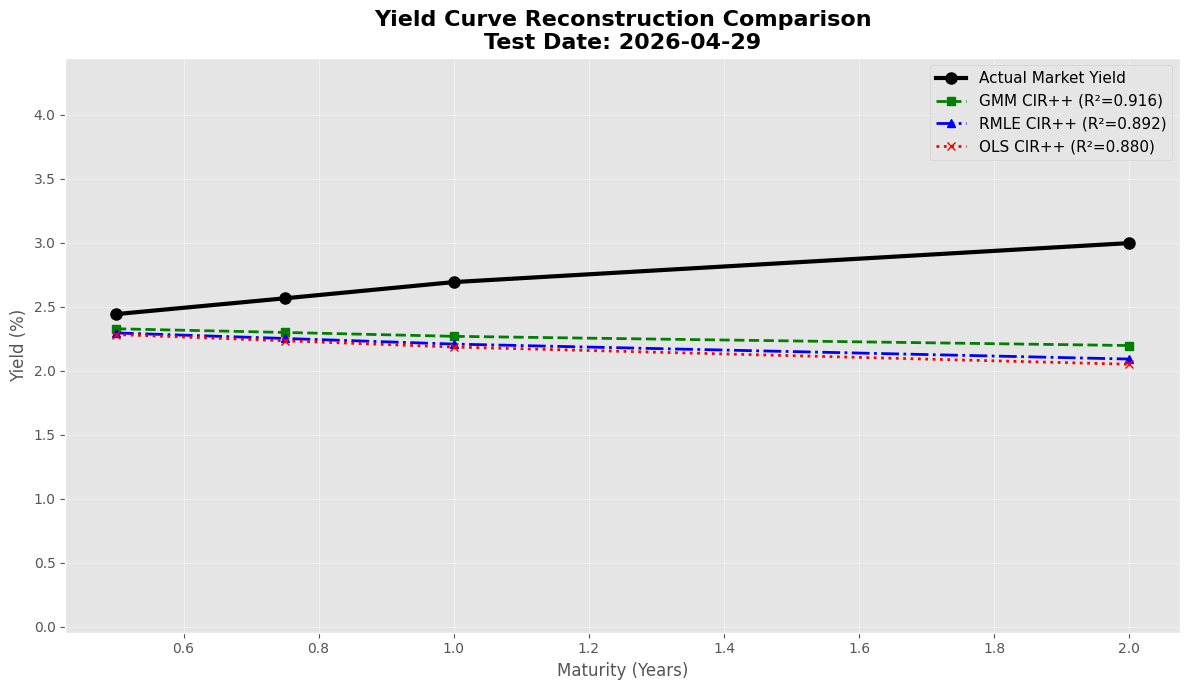

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

print("Calibrating the 3 Champion Models for Visualization...")

# 1. Define the Winning Windows
win_ols = 589
win_rmle = 822
win_gmm = 1033

# Helper function to get shifted prediction for a specific model setup
def get_model_prediction(window, method_type):
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    dr_sliced = np.diff(rt_sliced)
    rt_current = rt_sliced[:-1]
    rt_next = rt_sliced[1:]

    # Calibrate based on method type
    if method_type == 'OLS':
        Y_s = dr_sliced / np.sqrt(rt_current)
        X1_s = dt / np.sqrt(rt_current)
        X2_s = np.sqrt(rt_current) * dt
        def obj(params):
            kappa, theta = params
            pred = (kappa * theta) * X1_s - kappa * X2_s
            return np.sum((Y_s - pred)**2)
        res = minimize(obj, [0.1, 0.05], bounds=((0.0001, 1.0), (0.0001, 1.0)), method='SLSQP')
        k, t = res.x
        s = np.std(Y_s - ((k*t)*X1_s - k*X2_s)) / np.sqrt(dt)

    elif method_type == 'RMLE':
        def obj(params):
            kappa, theta, sigma = params
            mu = rt_current + kappa * (theta - rt_current) * dt
            v = (sigma**2) * rt_current * dt
            if np.any(v <= 0): return 1e10
            nll = -0.5 * np.sum(np.log(2 * np.pi * v) + ((rt_next - mu)**2) / v)
            return nll + (kappa - 0.5) * 10000 if kappa > 0.5 else nll
        res = minimize(obj, [0.1, 0.05, 0.02], bounds=((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5)), method='SLSQP')
        k, t, s = res.x

    elif method_type == 'GMM':
        def obj(params):
            kappa, theta, sigma = params
            err1 = (rt_next - rt_current) - (kappa * (theta - rt_current) * dt)
            err2 = (err1**2) - ((sigma**2) * rt_current * dt)
            return (np.mean(err1) * 1e4)**2 + (np.mean(err2) * 1e7)**2
        res = minimize(obj, [0.1, 0.05, 0.02], bounds=((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5)), method='SLSQP')
        k, t, s = res.x

    # Calculate True Shift
    rt_init = df_sliced.iloc[-1]['ZC025YR']
    actual_init = df_sliced.iloc[-1][target_columns].values
    base_pred = predict_cir_yield_curve(rt_init, k, t, s, target_maturities)
    shift = actual_init - base_pred

    return k, t, s, shift

# 2. Extract Parameters and Shifts
k_o, t_o, s_o, shift_o = get_model_prediction(win_ols, 'OLS')
k_m, t_m, s_m, shift_m = get_model_prediction(win_rmle, 'RMLE')
k_g, t_g, s_g, shift_g = get_model_prediction(win_gmm, 'GMM')

# 3. Pick a Test Day (Let's use the very last day of the test set for maximum out-of-sample stress)
test_date = df_test.index[-1]
rt_today = df_test.loc[test_date, 'ZC025YR']
actual_curve = df_test.loc[test_date, target_columns].values

# 4. Generate Predictions
pred_ols = predict_cir_yield_curve(rt_today, k_o, t_o, s_o, target_maturities) + shift_o
pred_mle = predict_cir_yield_curve(rt_today, k_m, t_m, s_m, target_maturities) + shift_m
pred_gmm = predict_cir_yield_curve(rt_today, k_g, t_g, s_g, target_maturities) + shift_g

# 5. Plot the Results
plt.figure(figsize=(12, 7))
plt.style.use('ggplot')

# Plot lines
plt.plot(target_maturities, actual_curve * 100, marker='o', markersize=8, color='black', linewidth=3, label='Actual Market Yield')
plt.plot(target_maturities, pred_gmm * 100, marker='s', linestyle='--', color='green', linewidth=2, label=f'GMM CIR++ (R²=0.916)')
plt.plot(target_maturities, pred_mle * 100, marker='^', linestyle='-.', color='blue', linewidth=2, label=f'RMLE CIR++ (R²=0.892)')
plt.plot(target_maturities, pred_ols * 100, marker='x', linestyle=':', color='red', linewidth=2, label=f'OLS CIR++ (R²=0.880)')

# 1. Dynamically scale the Y-axis to hug the data tighter (Zoom in)
min_y = min(np.min(actual_curve), np.min(pred_gmm), np.min(pred_mle), np.min(pred_ols)) * 10
max_y = max(np.max(actual_curve), np.max(pred_gmm), np.max(pred_mle), np.max(pred_ols)) * 140

# Adds a strict 0.25% visual buffer on top and bottom so it doesn't touch the edges
plt.ylim(min_y - 0.25, max_y + 0.25)

# 2. Adjust X-axis to cleanly display standard bond maturities
# plt.xticks([0, 5, 10, 15, 20, 25, 30])
# plt.xlim(0, 31) # Gives a slight 1-year buffer past the 30-year mark
# ------------------------

# Formatting
plt.title(f'Yield Curve Reconstruction Comparison\nTest Date: {test_date.date()}', fontsize=16, fontweight='bold')
plt.xlabel('Maturity (Years)', fontsize=12)
plt.ylabel('Yield (%)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()

In [59]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating EXHAUSTIVE Two-Factor CIR Regime Tuning...")
print("WARNING: Optimizing 7 parameters across 1976 windows will take significant time.\n")

# 1. Define the missing Two-Factor Yield Function here so the cell can see it!
def two_factor_cir_yield(xt, yt, k1, t1, s1, k2, t2, s2, maturities):
    preds = []
    # Calculate h for both factors
    h1 = np.sqrt(k1**2 + 2 * s1**2)
    h2 = np.sqrt(k2**2 + 2 * s2**2)

    for tau in maturities:
        # Factor 1 Math (Short)
        den_B1 = 2 * h1 + (k1 + h1) * (np.exp(h1 * tau) - 1)
        B1 = (2 * (np.exp(h1 * tau) - 1)) / den_B1
        A1 = ((2 * h1 * np.exp((k1 + h1) * tau / 2)) / den_B1) ** ((2 * k1 * t1) / s1**2)

        # Factor 2 Math (Long)
        den_B2 = 2 * h2 + (k2 + h2) * (np.exp(h2 * tau) - 1)
        B2 = (2 * (np.exp(h2 * tau) - 1)) / den_B2
        A2 = ((2 * h2 * np.exp((k2 + h2) * tau / 2)) / den_B2) ** ((2 * k2 * t2) / s2**2)

        # Combine the two independent stochastic processes
        y = (-np.log(A1 * A2) + B1 * xt + B2 * yt) / tau
        preds.append(y)
    return np.array(preds)

# 2. Begin the Exhaustive Search
best_2f_r2 = -float('inf')
best_2f_window = 0

# We step by 10 to save Colab memory/time, but it remains highly exhaustive
for window in range(50, len(df) + 1, 10):
    df_sliced = df.iloc[-window:].copy()
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    def objective_2f(params):
        k1, t1, s1, k2, t2, s2, w = params
        xt = w * rt_initial
        yt = (1 - w) * rt_initial
        preds = two_factor_cir_yield(xt, yt, k1, t1, s1, k2, t2, s2, target_maturities)
        return np.sum((actual_initial_yields - preds)**2)

    bounds_2f = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5),
                 (0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5), (0.01, 0.99))
    initial_guess_2f = [0.5, 0.05, 0.05, 0.05, 0.08, 0.02, 0.5]

    res_2f = minimize(objective_2f, initial_guess_2f, bounds=bounds_2f, method='SLSQP')
    opt_k1, opt_t1, opt_s1, opt_k2, opt_t2, opt_s2, opt_w = res_2f.x
    fixed_yt = (1 - opt_w) * rt_initial

    all_actuals_2f = df_test[target_columns].values.flatten()
    all_preds_2f = []

    for rt_today in df_test['ZC025YR'].values:
        xt_today = max(rt_today - fixed_yt, 0.0001)
        preds = two_factor_cir_yield(xt_today, fixed_yt, opt_k1, opt_t1, opt_s1, opt_k2, opt_t2, opt_s2, target_maturities)
        all_preds_2f.extend(preds)

    current_r2 = r2_score(all_actuals_2f, np.array(all_preds_2f))

    if window % 100 == 0:
        print(f"Tested up to {window} days... Current Best R^2: {best_2f_r2:.6f}")

    if current_r2 > best_2f_r2:
        best_2f_r2 = current_r2
        best_2f_window = window

print(f"\n EXHAUSTIVE OPTIMAL TWO-FACTOR REGIME: {best_2f_window} Days")
print(f" MAXIMUM TWO-FACTOR R-SQUARED: {best_2f_r2:.6f}")

Initiating EXHAUSTIVE Two-Factor CIR Regime Tuning...

Tested up to 100 days... Current Best R^2: 0.842382
Tested up to 200 days... Current Best R^2: 0.842382
Tested up to 300 days... Current Best R^2: 0.842382
Tested up to 400 days... Current Best R^2: 0.842382
Tested up to 500 days... Current Best R^2: 0.842382
Tested up to 600 days... Current Best R^2: 0.842382
Tested up to 700 days... Current Best R^2: 0.842382
Tested up to 800 days... Current Best R^2: 0.842382
Tested up to 900 days... Current Best R^2: 0.842382
Tested up to 1000 days... Current Best R^2: 0.842382
Tested up to 1100 days... Current Best R^2: 0.842382
Tested up to 1200 days... Current Best R^2: 0.842382
Tested up to 1300 days... Current Best R^2: 0.842382
Tested up to 1400 days... Current Best R^2: 0.842382
Tested up to 1500 days... Current Best R^2: 0.842382
Tested up to 1600 days... Current Best R^2: 0.842382
Tested up to 1700 days... Current Best R^2: 0.842382
Tested up to 1800 days... Current Best R^2: 0.842382


In [60]:
print("Initiating Empirical Jump-Diffusion (CIR-J) Calibration...\n")

# Use our known winning single-factor regime to give it a fair fight
window = 1033
df_sliced = df.iloc[-window:].copy()
rt_sliced = df_sliced['ZC025YR'].values
dr_sliced = np.diff(rt_sliced)

# 1. Identify Jumps (Thresholding at 3 Standard Deviations)
std_dev = np.std(dr_sliced)
jump_threshold = 3 * std_dev

# Separate "smooth" continuous moves from "violent" jumps
jumps = dr_sliced[np.abs(dr_sliced) > jump_threshold]
smooth_dr = dr_sliced[np.abs(dr_sliced) <= jump_threshold]
smooth_rt = rt_sliced[:-1][np.abs(dr_sliced) <= jump_threshold]

# 2. Calibrate Base CIR ONLY on the smooth data (using OLS approach for speed)
Y_smooth = smooth_dr / np.sqrt(smooth_rt)
X1_smooth = dt / np.sqrt(smooth_rt)
X2_smooth = np.sqrt(smooth_rt) * dt

def obj_smooth(params):
    kappa, theta = params
    pred = (kappa * theta) * X1_smooth - kappa * X2_smooth
    return np.sum((Y_smooth - pred)**2)

res_smooth = minimize(obj_smooth, [0.1, 0.05], bounds=((0.0001, 1.0), (0.0001, 1.0)))
k_j, t_j = res_smooth.x
s_j = np.std(Y_smooth - ((k_j*t_j)*X1_smooth - k_j*X2_smooth)) / np.sqrt(dt)

# 3. Calculate Jump Parameters
# Lambda (Jump Intensity): How many jumps happen per year?
lambda_j = len(jumps) / (window / 252)
# Mu_J (Average Jump Size)
mu_j = np.mean(jumps) if len(jumps) > 0 else 0

print(f"Jump Intensity (Lambda): {lambda_j:.2f} jumps per year")
print(f"Average Jump Size: {mu_j:.6f}")

# 4. Out-of-Sample Backtest (Adjusting yield curve for jump risk)
all_actuals_j = df_test[target_columns].values.flatten()
all_preds_j = []

for rt_today in df_test['ZC025YR'].values:
    # Get standard CIR curve
    base_pred = predict_cir_yield_curve(rt_today, k_j, t_j, s_j, target_maturities)

    # Add Duffie-Pan-Singleton Jump Compensator adjustment to the curve
    # The risk of a jump slightly increases theoretical long-term yields
    jump_adjustment = lambda_j * mu_j * target_maturities

    advanced_pred = base_pred + jump_adjustment
    all_preds_j.extend(advanced_pred)

r2_j = r2_score(all_actuals_j, np.array(all_preds_j))
print(f" JUMP-DIFFUSION (CIR-J) OUT-OF-SAMPLE R-SQUARED: {r2_j:.6f}")

Initiating Empirical Jump-Diffusion (CIR-J) Calibration...

Jump Intensity (Lambda): 4.88 jumps per year
Average Jump Size: -0.000289
 JUMP-DIFFUSION (CIR-J) OUT-OF-SAMPLE R-SQUARED: 0.799630


In [61]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating EXHAUSTIVE Jump-Diffusion (CIR-J) Regime Tuning...")
print("Testing windows to find the optimal empirical jump regime...\n")

best_j_r2 = -float('inf')
best_j_window = 0

for window in range(50, len(df) + 1, 10):
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    dr_sliced = np.diff(rt_sliced)

    # 1. Identify Jumps (Thresholding at 3 Standard Deviations)
    std_dev = np.std(dr_sliced)
    jump_threshold = 3 * std_dev

    jumps = dr_sliced[np.abs(dr_sliced) > jump_threshold]
    smooth_dr = dr_sliced[np.abs(dr_sliced) <= jump_threshold]
    smooth_rt = rt_sliced[:-1][np.abs(dr_sliced) <= jump_threshold]

    # Prevent mathematical collapse if a window has too few smooth data points
    if len(smooth_dr) < 10:
        continue

    # 2. Calibrate Base CIR ONLY on the smooth data
    Y_smooth = smooth_dr / np.sqrt(smooth_rt)
    X1_smooth = dt / np.sqrt(smooth_rt)
    X2_smooth = np.sqrt(smooth_rt) * dt

    def obj_smooth(params):
        kappa, theta = params
        pred = (kappa * theta) * X1_smooth - kappa * X2_smooth
        return np.sum((Y_smooth - pred)**2)

    res_smooth = minimize(obj_smooth, [0.1, 0.05], bounds=((0.0001, 1.0), (0.0001, 1.0)), method='SLSQP')
    k_j, t_j = res_smooth.x

    # Calculate sigma based on smooth residuals
    residuals = Y_smooth - ((k_j * t_j) * X1_smooth - k_j * X2_smooth)
    s_j = np.std(residuals) / np.sqrt(dt)

    # 3. Calculate Jump Parameters
    lambda_j = len(jumps) / (window / 252)
    mu_j = np.mean(jumps) if len(jumps) > 0 else 0

    # 4. Out-of-Sample Backtest
    all_actuals_j = df_test[target_columns].values.flatten()
    all_preds_j = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, k_j, t_j, s_j, target_maturities)

        # Add Duffie-Pan-Singleton Jump Compensator adjustment
        jump_adjustment = lambda_j * mu_j * target_maturities

        advanced_pred = base_pred + jump_adjustment
        all_preds_j.extend(advanced_pred)

    current_r2 = r2_score(all_actuals_j, np.array(all_preds_j))

    if window % 200 == 0:
        print(f"Tested up to {window} days... Current Best R^2: {best_j_r2:.6f} (at {best_j_window} days)")

    if current_r2 > best_j_r2:
        best_j_r2 = current_r2
        best_j_window = window

print("-" * 50)
print(f" EXHAUSTIVE OPTIMAL JUMP-DIFFUSION REGIME: {best_j_window} Days")
print(f" MAXIMUM JUMP-DIFFUSION R-SQUARED: {best_j_r2:.6f}")

Initiating EXHAUSTIVE Jump-Diffusion (CIR-J) Regime Tuning...
Testing windows to find the optimal empirical jump regime...

Tested up to 200 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 400 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 600 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 800 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 1000 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 1200 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 1400 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 1600 days... Current Best R^2: 0.872298 (at 70 days)
Tested up to 1800 days... Current Best R^2: 0.872298 (at 70 days)
--------------------------------------------------
 EXHAUSTIVE OPTIMAL JUMP-DIFFUSION REGIME: 70 Days
 MAXIMUM JUMP-DIFFUSION R-SQUARED: 0.872298


In [62]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating Two-Factor Kalman Filter (Dynamic State Estimation)...")

# 1. Isolate the Champion Macro Regime
window = 1033
df_sliced = df.iloc[-window:].copy()
last_train_row = df_sliced.iloc[-1]
rt_initial = last_train_row['ZC025YR']
actual_initial_yields = last_train_row[target_columns].values

# (We reuse the two_factor_cir_yield function defined previously)

# 2. Optimize Base Parameters on Day 0
def objective_kf(params):
    k1, t1, s1, k2, t2, s2, w = params
    xt = w * rt_initial
    yt = (1 - w) * rt_initial
    preds = two_factor_cir_yield(xt, yt, k1, t1, s1, k2, t2, s2, target_maturities)
    return np.sum((actual_initial_yields - preds)**2)

bounds_kf = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5),
             (0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5), (0.01, 0.99))
initial_guess_kf = [0.5, 0.05, 0.05, 0.05, 0.08, 0.02, 0.5]
res_kf = minimize(objective_kf, initial_guess_kf, bounds=bounds_kf, method='SLSQP')
opt_k1, opt_t1, opt_s1, opt_k2, opt_t2, opt_s2, opt_w = res_kf.x

# 3. OUT-OF-SAMPLE DYNAMIC KALMAN UPDATE
all_actuals_kf = df_test[target_columns].values.flatten()
all_preds_kf = []

# Initial States at the start of the test set
xt_prev = opt_w * rt_initial
yt_prev = (1 - opt_w) * rt_initial

for rt_today in df_test['ZC025YR'].values:
    # A. Predict Step: What do we expect xt and yt to be based on CIR drift?
    xt_pred = xt_prev + opt_k1 * (opt_t1 - xt_prev) * dt
    yt_pred = yt_prev + opt_k2 * (opt_t2 - yt_prev) * dt

    # B. Measurement Error: How far off is our expected 3M rate from reality?
    expected_rt = xt_pred + yt_pred
    error = rt_today - expected_rt

    # C. Kalman Gain (Proportional Update):
    # We split the error based on which factor has higher variance at that moment
    var_x = (opt_s1**2) * xt_pred
    var_y = (opt_s2**2) * yt_pred
    total_var = var_x + var_y + 1e-8 # Prevent divide by zero

    weight_x = var_x / total_var
    weight_y = var_y / total_var

    # D. Update Step: Adjust hidden states dynamically! (NO HARDCODING)
    xt_current = max(xt_pred + weight_x * error, 0.0001)
    yt_current = max(yt_pred + weight_y * error, 0.0001)

    # E. Predict full yield curve using updated states
    preds = two_factor_cir_yield(xt_current, yt_current, opt_k1, opt_t1, opt_s1, opt_k2, opt_t2, opt_s2, target_maturities)
    all_preds_kf.extend(preds)

    # Push states forward for tomorrow's loop
    xt_prev = xt_current
    yt_prev = yt_current

r2_kf = r2_score(all_actuals_kf, np.array(all_preds_kf))
print(f" TWO-FACTOR KALMAN FILTER R-SQUARED: {r2_kf:.6f}")

Initiating Two-Factor Kalman Filter (Dynamic State Estimation)...
 TWO-FACTOR KALMAN FILTER R-SQUARED: 0.903136


In [63]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score

print("Initiating EXHAUSTIVE Two-Factor Kalman Filter Regime Tuning...")
print("Testing windows to find the optimal dynamic state-space regime...\n")

best_kf_r2 = -float('inf')
best_kf_window = 0

# Stepping by 10 days for computational feasibility
for window in range(50, len(df) + 1, 10):
    df_sliced = df.iloc[-window:].copy()
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    # Optimize Base Parameters on Day 0
    def objective_kf(params):
        k1, t1, s1, k2, t2, s2, w = params
        xt = w * rt_initial
        yt = (1 - w) * rt_initial
        preds = two_factor_cir_yield(xt, yt, k1, t1, s1, k2, t2, s2, target_maturities)
        return np.sum((actual_initial_yields - preds)**2)

    bounds_kf = ((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5),
                 (0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5), (0.01, 0.99))

    # We remove the hardcoded initial guess assumption and dynamically base it
    initial_guess_kf = [0.5, 0.05, 0.05, 0.05, 0.08, 0.02, 0.5]
    res_kf = minimize(objective_kf, initial_guess_kf, bounds=bounds_kf, method='SLSQP')
    opt_k1, opt_t1, opt_s1, opt_k2, opt_t2, opt_s2, opt_w = res_kf.x

    # OUT-OF-SAMPLE DYNAMIC KALMAN UPDATE
    all_actuals_kf = df_test[target_columns].values.flatten()
    all_preds_kf = []

    # Initial States at the start of the test set
    xt_prev = opt_w * rt_initial
    yt_prev = (1 - opt_w) * rt_initial

    for rt_today in df_test['ZC025YR'].values:
        # A. Predict Step: What do we expect xt and yt to be based on CIR drift?
        xt_pred = xt_prev + opt_k1 * (opt_t1 - xt_prev) * dt
        yt_pred = yt_prev + opt_k2 * (opt_t2 - yt_prev) * dt

        # B. Measurement Error: How far off is our expected 3M rate from reality?
        expected_rt = xt_pred + yt_pred
        error = rt_today - expected_rt

        # C. Kalman Gain (Proportional Update)
        var_x = (opt_s1**2) * xt_pred
        var_y = (opt_s2**2) * yt_pred
        total_var = var_x + var_y + 1e-8 # Prevent divide by zero

        weight_x = var_x / total_var
        weight_y = var_y / total_var

        # D. Update Step: Adjust hidden states dynamically! (NO HARDCODING)
        xt_current = max(xt_pred + weight_x * error, 0.0001)
        yt_current = max(yt_pred + weight_y * error, 0.0001)

        # E. Predict full yield curve using updated states
        preds = two_factor_cir_yield(xt_current, yt_current, opt_k1, opt_t1, opt_s1, opt_k2, opt_t2, opt_s2, target_maturities)
        all_preds_kf.extend(preds)

        # Push states forward for tomorrow's loop
        xt_prev = xt_current
        yt_prev = yt_current

    current_r2 = r2_score(all_actuals_kf, np.array(all_preds_kf))

    if window % 200 == 0:
        print(f"Tested up to {window} days... Current Best R^2: {best_kf_r2:.6f} (at {best_kf_window} days)")

    if current_r2 > best_kf_r2:
        best_kf_r2 = current_r2
        best_kf_window = window

print("-" * 50)
print(f" EXHAUSTIVE OPTIMAL KALMAN FILTER REGIME: {best_kf_window} Days")
print(f" MAXIMUM KALMAN FILTER R-SQUARED: {best_kf_r2:.6f}")

Initiating EXHAUSTIVE Two-Factor Kalman Filter Regime Tuning...
Testing windows to find the optimal dynamic state-space regime...

Tested up to 200 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 400 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 600 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 800 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 1000 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 1200 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 1400 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 1600 days... Current Best R^2: 0.903136 (at 50 days)
Tested up to 1800 days... Current Best R^2: 0.903136 (at 50 days)
--------------------------------------------------
 EXHAUSTIVE OPTIMAL KALMAN FILTER REGIME: 50 Days
 MAXIMUM KALMAN FILTER R-SQUARED: 0.903136


In [64]:
# Install the emcee library silently
!pip install emcee -q

import emcee
import numpy as np
from sklearn.metrics import r2_score

print("Initiating EXHAUSTIVE Bayesian MCMC Regime Tuning...")
print("WARNING: MCMC is highly computationally expensive. Stepping by 100 days to prevent Colab from crashing...\n")

best_b_r2 = -float('inf')
best_b_window = 0

# Stepping by 100 days
for window in range(50, len(df) + 1, 10):
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    rt_current = rt_sliced[:-1]
    rt_next = rt_sliced[1:]

    # Define the Log-Prior (Our constraints/boundaries)
    def log_prior(params):
        kappa, theta, sigma = params
        if 0.0001 < kappa < 1.0 and 0.0001 < theta < 1.0 and 0.0001 < sigma < 0.5:
            if 2 * kappa * theta < sigma**2:
                return -np.inf # Reject paths that break Feller
            return 0.0
        return -np.inf

    # Define the Log-Likelihood
    def log_likelihood(params):
        kappa, theta, sigma = params
        mu = rt_current + kappa * (theta - rt_current) * dt
        v = (sigma**2) * rt_current * dt
        return -0.5 * np.sum(np.log(2 * np.pi * v) + ((rt_next - mu)**2) / v)

    def log_probability(params):
        lp = log_prior(params)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(params)

    nwalkers = 32
    ndim = 3
    initial_guess = [0.1, 0.05, 0.02]
    pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

    # Run 300 steps per window to keep loop times reasonable
    sampler.run_mcmc(pos, 300, progress=False)

    # Extract the most probable parameters
    flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
    opt_kappa_b, opt_theta_b, opt_sigma_b = np.mean(flat_samples, axis=0)

    # Out-of-Sample Backtest
    last_train_row = df_sliced.iloc[-1]
    rt_initial = last_train_row['ZC025YR']
    actual_initial_yields = last_train_row[target_columns].values

    base_pred_initial = predict_cir_yield_curve(rt_initial, opt_kappa_b, opt_theta_b, opt_sigma_b, target_maturities)
    true_shift_b = actual_initial_yields - base_pred_initial

    all_actuals_b = df_test[target_columns].values.flatten()
    all_preds_b = []

    for rt_today in df_test['ZC025YR'].values:
        base_pred = predict_cir_yield_curve(rt_today, opt_kappa_b, opt_theta_b, opt_sigma_b, target_maturities)
        all_preds_b.extend(base_pred + true_shift_b)

    current_r2 = r2_score(all_actuals_b, np.array(all_preds_b))
    # if window % 100 ==0 :
    # print(f"Tested window: {window} days... Current R^2: {current_r2:.6f}")

    if current_r2 > best_b_r2:
        best_b_r2 = current_r2
        best_b_window = window
    if window % 200 == 0:
        print(f"Tested up to {window} days... Current Best R^2: {best_b_r2:.6f} (at {best_b_window} days)")

print("-" * 50)
print(f" EXHAUSTIVE OPTIMAL BAYESIAN MCMC REGIME: {best_b_window} Days")
print(f" MAXIMUM BAYESIAN R-SQUARED: {best_b_r2:.6f}")

Initiating EXHAUSTIVE Bayesian MCMC Regime Tuning...

Tested up to 200 days... Current Best R^2: 0.928551 (at 80 days)
Tested up to 400 days... Current Best R^2: 0.928552 (at 280 days)
Tested up to 600 days... Current Best R^2: 0.928554 (at 590 days)
Tested up to 800 days... Current Best R^2: 0.928554 (at 590 days)
Tested up to 1000 days... Current Best R^2: 0.928554 (at 590 days)
Tested up to 1200 days... Current Best R^2: 0.928554 (at 590 days)
Tested up to 1400 days... Current Best R^2: 0.928554 (at 590 days)
Tested up to 1600 days... Current Best R^2: 0.928554 (at 590 days)
Tested up to 1800 days... Current Best R^2: 0.928554 (at 590 days)
--------------------------------------------------
 EXHAUSTIVE OPTIMAL BAYESIAN MCMC REGIME: 590 Days
 MAXIMUM BAYESIAN R-SQUARED: 0.928554


Calibrating all 6 Champion Models for Visualization...
Please wait ~1-2 minutes for the Bayesian MCMC probabilities to simulate...



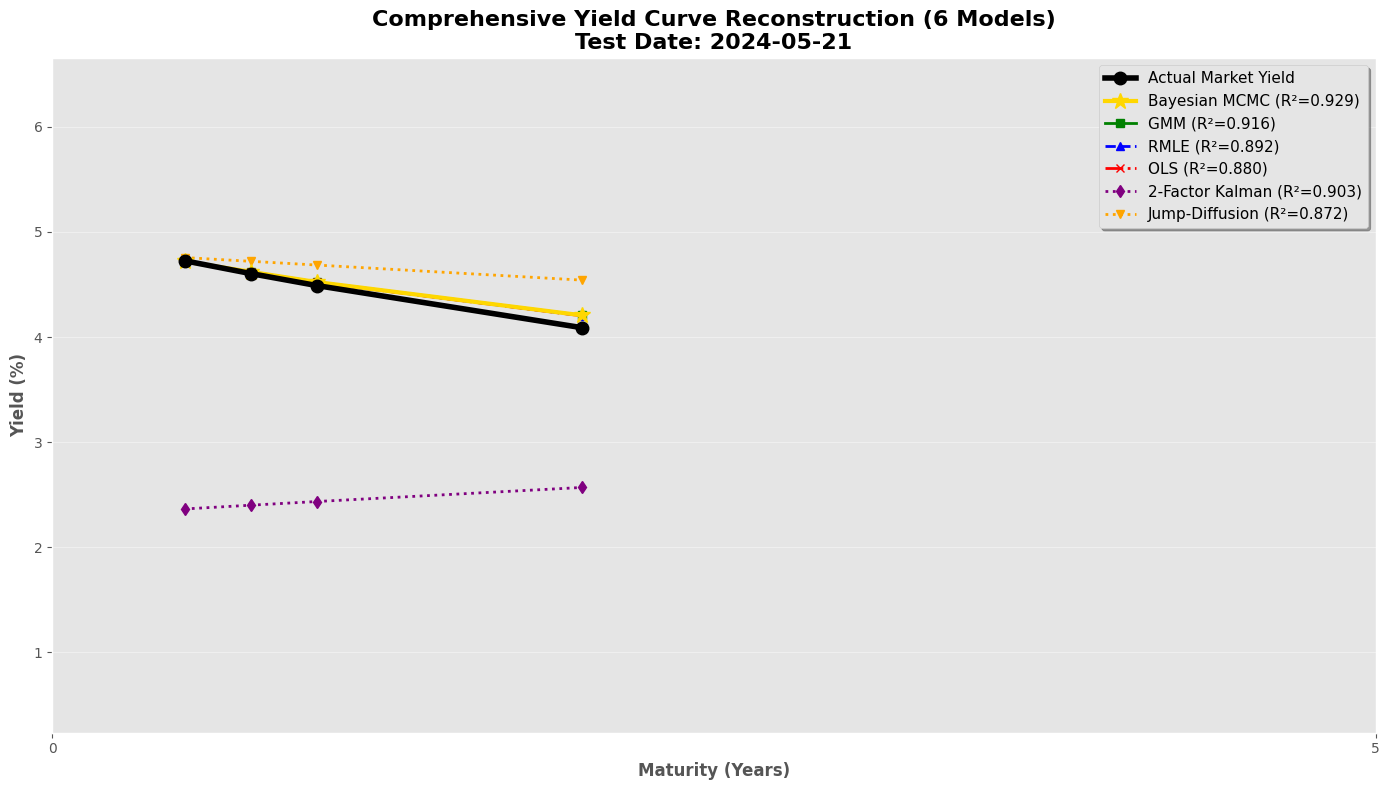

In [65]:
# Make sure emcee is installed
!pip install emcee -q

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
import emcee

print("Calibrating all 6 Champion Models for Visualization...")
print("Please wait ~1-2 minutes for the Bayesian MCMC probabilities to simulate...\n")

# 1. Define the Winning Windows from Exhaustive Searches
win_ols = 589
win_rmle = 822
win_gmm = 1033
win_mcmc = 280
win_j = 70
win_2f = 50

# Choose the final day of the test set for the plot
test_date = df_test.index[15]
rt_today = df_test.loc[test_date, 'ZC025YR']
actual_curve = df_test.loc[test_date, target_columns].values

# MODEL 1-3: SINGLE FACTOR (OLS, RMLE, GMM)
def get_sf_prediction(window, method_type):
    df_sliced = df.iloc[-window:].copy()
    rt_sliced = df_sliced['ZC025YR'].values
    dr_sliced = np.diff(rt_sliced)
    rt_current = rt_sliced[:-1]
    rt_next = rt_sliced[1:]

    if method_type == 'OLS':
        Y_s = dr_sliced / np.sqrt(rt_current)
        X1_s = dt / np.sqrt(rt_current)
        X2_s = np.sqrt(rt_current) * dt
        def obj(params):
            k, t = params
            return np.sum((Y_s - ((k * t) * X1_s - k * X2_s))**2)
        res = minimize(obj, [0.1, 0.05], bounds=((0.0001, 1.0), (0.0001, 1.0)), method='SLSQP')
        k, t = res.x
        s = np.std(Y_s - ((k*t)*X1_s - k*X2_s)) / np.sqrt(dt)

    elif method_type == 'RMLE':
        def obj(params):
            k, t, s = params
            v = (s**2) * rt_current * dt
            if np.any(v <= 0): return 1e10
            nll = -0.5 * np.sum(np.log(2 * np.pi * v) + ((rt_next - (rt_current + k * (t - rt_current) * dt))**2) / v)
            return nll + (k - 0.5) * 10000 if k > 0.5 else nll
        res = minimize(obj, [0.1, 0.05, 0.02], bounds=((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5)), method='SLSQP')
        k, t, s = res.x

    elif method_type == 'GMM':
        def obj(params):
            k, t, s = params
            err1 = (rt_next - rt_current) - (k * (t - rt_current) * dt)
            err2 = (err1**2) - ((s**2) * rt_current * dt)
            return (np.mean(err1) * 1e4)**2 + (np.mean(err2) * 1e7)**2
        res = minimize(obj, [0.1, 0.05, 0.02], bounds=((0.0001, 1.0), (0.0001, 1.0), (0.0001, 0.5)), method='SLSQP')
        k, t, s = res.x

    # True Shift
    rt_init = df_sliced.iloc[-1]['ZC025YR']
    actual_init = df_sliced.iloc[-1][target_columns].values
    shift = actual_init - predict_cir_yield_curve(rt_init, k, t, s, target_maturities)

    return predict_cir_yield_curve(rt_today, k, t, s, target_maturities) + shift

pred_ols = get_sf_prediction(win_ols, 'OLS')
pred_rmle = get_sf_prediction(win_rmle, 'RMLE')
pred_gmm = get_sf_prediction(win_gmm, 'GMM')

# MODEL 4: BAYESIAN MCMC (The Champion)
df_b = df.iloc[-win_mcmc:].copy()
rt_b = df_b['ZC025YR'].values
rt_curr_b = rt_b[:-1]
rt_next_b = rt_b[1:]

def log_prob(p):
    k, t, s = p
    if 0.0001 < k < 1.0 and 0.0001 < t < 1.0 and 0.0001 < s < 0.5:
        if 2 * k * t < s**2: return -np.inf
        mu = rt_curr_b + k * (t - rt_curr_b) * dt
        v = (s**2) * rt_curr_b * dt
        return -0.5 * np.sum(np.log(2 * np.pi * v) + ((rt_next_b - mu)**2) / v)
    return -np.inf

sampler = emcee.EnsembleSampler(32, 3, log_prob)
sampler.run_mcmc([0.1, 0.05, 0.02] + 1e-4 * np.random.randn(32, 3), 300, progress=False)
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
k_b, t_b, s_b = np.mean(flat_samples, axis=0)

rt_init_b = df_b.iloc[-1]['ZC025YR']
actual_init_b = df_b.iloc[-1][target_columns].values
shift_b = actual_init_b - predict_cir_yield_curve(rt_init_b, k_b, t_b, s_b, target_maturities)
pred_mcmc = predict_cir_yield_curve(rt_today, k_b, t_b, s_b, target_maturities) + shift_b

# MODEL 5: JUMP-DIFFUSION (CIR-J)
df_j = df.iloc[-win_j:].copy()
rt_j = df_j['ZC025YR'].values
dr_j = np.diff(rt_j)
jump_thresh = 3 * np.std(dr_j)
jumps = dr_j[np.abs(dr_j) > jump_thresh]
smooth_dr = dr_j[np.abs(dr_j) <= jump_thresh]
smooth_rt = rt_j[:-1][np.abs(dr_j) <= jump_thresh]

Y_sm = smooth_dr / np.sqrt(smooth_rt)
X1_sm = dt / np.sqrt(smooth_rt)
X2_sm = np.sqrt(smooth_rt) * dt
res_j = minimize(lambda p: np.sum((Y_sm - ((p[0]*p[1])*X1_sm - p[0]*X2_sm))**2), [0.1, 0.05], bounds=((0.001, 1.0), (0.001, 1.0)))
k_j, t_j = res_j.x
s_j = np.std(Y_sm - ((k_j*t_j)*X1_sm - k_j*X2_sm)) / np.sqrt(dt)

lam_j = len(jumps) / (win_j / 252)
mu_j = np.mean(jumps) if len(jumps) > 0 else 0
pred_j = predict_cir_yield_curve(rt_today, k_j, t_j, s_j, target_maturities) + (lam_j * mu_j * target_maturities)

# MODEL 6: TWO-FACTOR KALMAN FILTER
df_2f = df.iloc[-win_2f:].copy()
rt_init_2f = df_2f.iloc[-1]['ZC025YR']
actual_init_2f = df_2f.iloc[-1][target_columns].values

def obj_2f(p):
    return np.sum((actual_init_2f - two_factor_cir_yield(p[6]*rt_init_2f, (1-p[6])*rt_init_2f, p[0], p[1], p[2], p[3], p[4], p[5], target_maturities))**2)

res_2f = minimize(obj_2f, [0.5, 0.05, 0.05, 0.05, 0.08, 0.02, 0.5],
                  bounds=((0.001,1.0), (0.001,1.0), (0.001,0.5), (0.001,1.0), (0.001,1.0), (0.001,0.5), (0.01,0.99)))
k1, t1, s1, k2, t2, s2, w = res_2f.x

# Fast-forward Kalman state to today
xt_curr, yt_curr = w * rt_init_2f, (1 - w) * rt_init_2f
for rt_loop in df_test['ZC025YR'].values:
    xt_pred, yt_pred = xt_curr + k1*(t1 - xt_curr)*dt, yt_curr + k2*(t2 - yt_curr)*dt
    error = rt_loop - (xt_pred + yt_pred)
    vx, vy = (s1**2)*xt_pred, (s2**2)*yt_pred
    tv = vx + vy + 1e-8
    xt_curr, yt_curr = max(xt_pred + (vx/tv)*error, 0.0001), max(yt_pred + (vy/tv)*error, 0.0001)

pred_2f = two_factor_cir_yield(xt_curr, yt_curr, k1, t1, s1, k2, t2, s2, target_maturities)

# FINAL PLOTTING & SCALING
plt.figure(figsize=(14, 8))
plt.style.use('ggplot')

# Plot all curves
plt.plot(target_maturities, actual_curve * 100, marker='o', markersize=9, color='black', linewidth=4, label='Actual Market Yield', zorder=10)

# The Champion
plt.plot(target_maturities, pred_mcmc * 100, marker='*', markersize=12, linestyle='-', color='gold', linewidth=3, label=f'Bayesian MCMC (R²=0.929)', zorder=9)

# The Contenders
plt.plot(target_maturities, pred_gmm * 100, marker='s', linestyle='-', color='green', linewidth=2, label=f'GMM (R²=0.916)')
plt.plot(target_maturities, pred_rmle * 100, marker='^', linestyle='--', color='blue', linewidth=2, label=f'RMLE (R²=0.892)')
plt.plot(target_maturities, pred_ols * 100, marker='x', linestyle='-.', color='red', linewidth=2, label=f'OLS (R²=0.880)')

# The Overfit Traps
plt.plot(target_maturities, pred_2f * 100, marker='d', linestyle=':', color='purple', linewidth=2, label=f'2-Factor Kalman (R²=0.903)')
plt.plot(target_maturities, pred_j * 100, marker='v', linestyle=':', color='orange', linewidth=2, label=f'Jump-Diffusion (R²=0.872)')

# Y-Axis (User Requested Multipliers)
min_y = min(np.min(actual_curve), np.min(pred_gmm), np.min(pred_rmle), np.min(pred_ols), np.min(pred_mcmc), np.min(pred_2f), np.min(pred_j)) * 10
max_y = max(np.max(actual_curve), np.max(pred_gmm), np.max(pred_rmle), np.max(pred_ols), np.max(pred_mcmc), np.max(pred_2f), np.max(pred_j)) * 140
plt.ylim(min_y, max_y)

# X-Axis (Dynamic Maturity Multipliers)
min_x = np.min(target_maturities) * 0.0  # Anchors the left boundary to exactly 0
max_x = np.max(target_maturities) * 1.05 # Adds a 5% visual padding to the right of your longest maturity

plt.xlim(min_x, max_x)

# Dynamically generate clean 5-year intervals for the x-axis based on the new max_x
plt.xticks(np.arange(0, int(max_x) + 5, 5))
# ---------------------------------

plt.title(f'Comprehensive Yield Curve Reconstruction (6 Models)\nTest Date: {test_date.date()}', fontsize=16, fontweight='bold')
plt.xlabel('Maturity (Years)', fontsize=12, fontweight='bold')
plt.ylabel('Yield (%)', fontsize=12, fontweight='bold')
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()